In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

from src.helpers import parse_edges
import src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tripinfo_am  = Path("/home/marta/tesi-5t/DTBaldissera/vm-file/project/scripts/output/simulation-out/out_MA_no_TLS/TripInfo_marouter_AM.xml")

tree = ET.parse(tripinfo_am)
root = tree.getroot()

info = []

for trip in root.findall("tripinfo"):
    info.append(
    {"id": float(trip.get("id")),
    "depart": float(trip.get("depart")),
    "departLane": str(trip.get("departLane")),
    "departPos": float(trip.get("departPos")),
    "arrival": float(trip.get("arrival")),
    "arrivalLane": str(trip.get("arrivalLane")),
    "arrivalPos": float(trip.get("arrivalPos")),
    "duration": float(trip.get("duration")),
    "routeLength": float(trip.get("routeLength")),
    "waitingTime": float(trip.get("waitingTime")),
    "timeLoss": float(trip.get("timeLoss")),
    })
    
df_res = pd.DataFrame(info)
df_res

,id,depart,departLane,departPos,arrival,arrivalLane,arrivalPos,duration,routeLength,waitingTime,timeLoss
0,17430.0,28805.0,121952572#3_0,0.46,28806.0,121952572#4_0,4.78,1.0,13.88,0.0,0.00
1,20695.0,28812.0,-1307179610#0_0,0.20,28815.0,134572330#0_0,0.20,3.0,10.00,0.0,1.98
2,1426.0,28806.0,1305781749_2,5.10,28820.0,36218413#2_0,17.46,14.0,300.72,0.0,0.68
3,23691.0,28820.0,134420434#22_0,2.72,28825.0,-145954704#13_0,12.60,5.0,27.40,0.0,2.86
4,19546.0,28803.0,-1307179605_0,1.60,28826.0,134572330#0_0,0.20,23.0,429.41,0.0,4.54
...,...,...,...,...,...,...,...,...,...,...,...
27582,6338.0,44263.0,83387809#0_0,5.10,45811.0,397430751#1_0,64.16,1548.0,2595.05,934.0,1353.52
27583,5021.0,44692.0,83387809#0_0,5.10,45815.0,1311112378#0_0,62.38,1123.0,2079.36,561.0,997.27
27584,5029.0,44791.0,83387809#0_0,5.10,45827.0,1311112378#0_0,62.38,1036.0,2079.36,466.0,906.77
27585,5043.0,44948.0,83387809#0_0,5.10,45837.0,1311112378#0_0,62.38,889.0,2079.36,322.0,757.88


In [3]:
import geopandas as gpd
edges = ET.parse(cfg.EDG_PARSE_XML).getroot()

edges_data = {}

for e in edges.findall("edge"):
    if e.attrib.get("function") == "internal":
        continue
    eid = e.get("id")
    fid = e.get("from")
    tid = e.get("to")
    type_e = e.get("type")
    
    for lane in e.findall("lane"):
        lid = lane.get("id")
        lane_index = lane.attrib.get("index")
        length = lane.attrib.get("length")
        speed = lane.attrib.get("speed")
        l_shape = lane.attrib.get("shape")
        
        lane_data = {
            "id_edge": eid,
            "index": lane_index,
            "from": fid,
            "to": tid,
            "name": e.attrib.get("name", ""),
            "numLanes": e.attrib.get("numLanes", ""),
            "speed": speed,
            "length": length,
            "shape": l_shape,
        }

        # key = lane_id, value = lane_data
        edges_data[lid] = lane_data
        
df_lanes = pd.DataFrame.from_dict(edges_data, orient="index")
df_lanes

,id_edge,index,from,to,name,numLanes,speed,length,shape
-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753..."
-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589..."
-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469..."
-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745..."
-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946..."
...,...,...,...,...,...,...,...,...,...
952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093..."
952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283..."
99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851..."
99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902..."


In [4]:
usage_depart = df_res.groupby("departLane").size().rename("n_inserted").reset_index()
usage_arrival = df_res.groupby("arrivalLane").size().rename("n_inserted").reset_index()
usage_depart

,departLane,n_inserted
0,-110531712#0_0,9
1,-110531712#1_0,8
2,-110531715_0,7
3,-111859620#0_0,1
4,-111859620#10_0,2
...,...,...
1039,913296515#1_1,10
1040,926267859#0_0,2
1041,99754717#0_0,11
1042,99754717#1_0,14


In [5]:
from shapely import LineString

df_lanes['geometry'] = df_lanes["shape"].apply(
        lambda shape: LineString(
                [tuple(map(float, coord.split(","))) for coord in shape.split()]
        )
)

gdf_lanes = gpd.GeoDataFrame(df_lanes, geometry="geometry", crs="EPSG:32632")
gdf_lanes = gdf_lanes.reset_index().rename(columns={"level_0": "lane_id"})

gdf_lanes

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)"
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)"
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)"
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)"
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)"
...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4..."
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ..."


In [6]:
gdf_usage_depart = gdf_lanes.merge(usage_depart, left_on="lane_id", right_on="departLane", how="left")
gdf_usage_depart["n_inserted"] = gdf_usage_depart["n_inserted"].fillna(0)

gdf_usage_depart

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,departLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",NaN,0.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",99754717#0_0,11.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",99754717#1_0,14.0


In [7]:
gdf_usage_arrival = gdf_lanes.merge(usage_arrival, left_on="lane_id", right_on="arrivalLane", how="left")
gdf_usage_arrival["n_inserted"] = gdf_usage_arrival["n_inserted"].fillna(0)

gdf_usage_arrival

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,arrivalLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,5.56,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,5.56,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,5.56,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,5.56,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",NaN,0.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,5.56,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,5.56,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",NaN,0.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",NaN,0.0


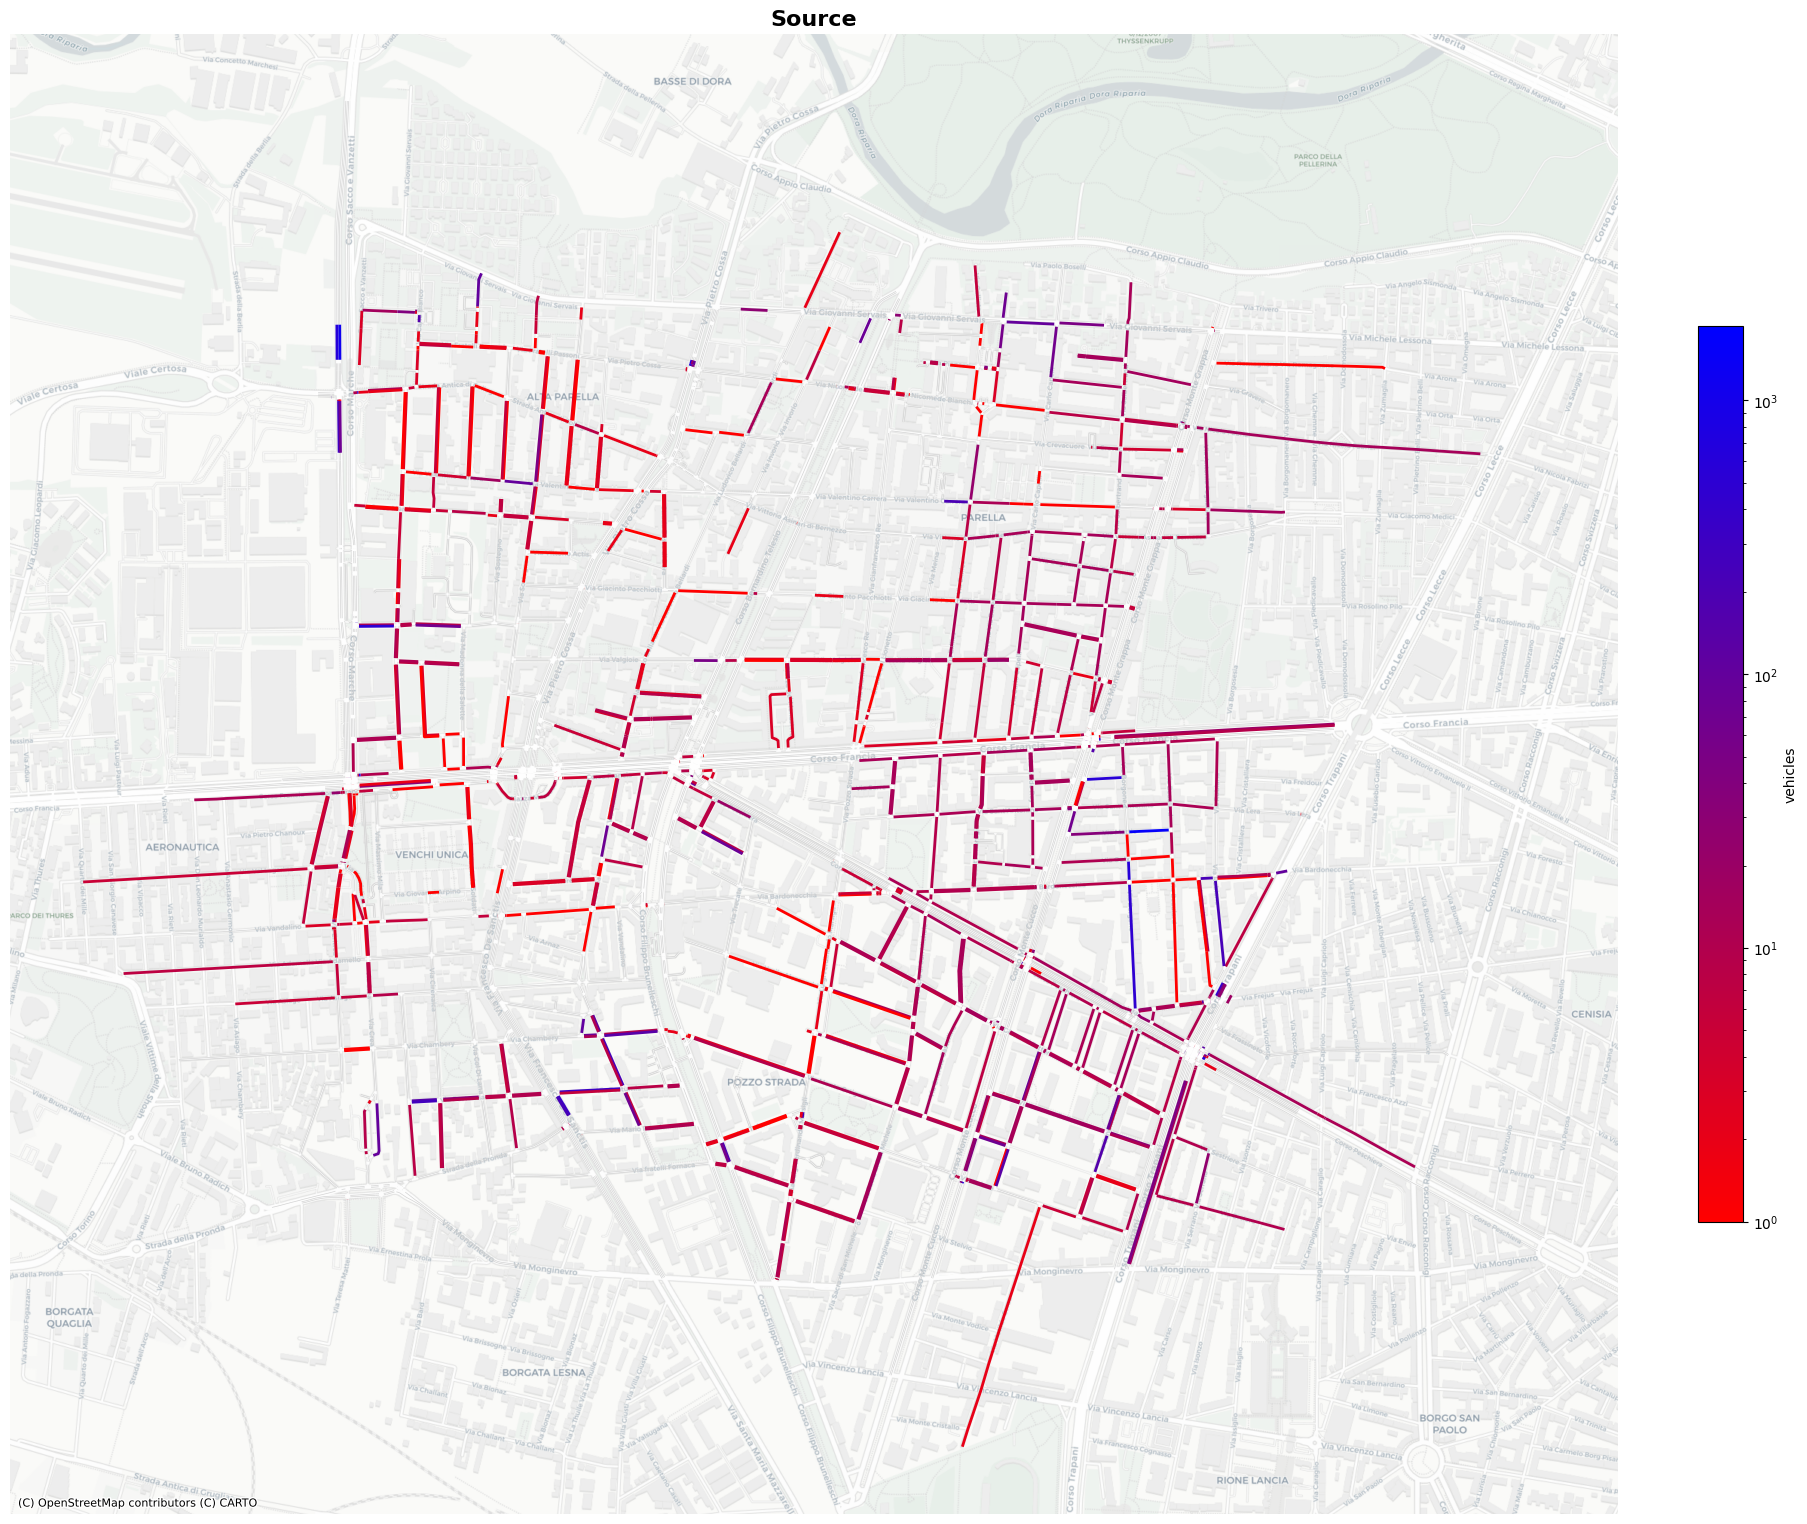

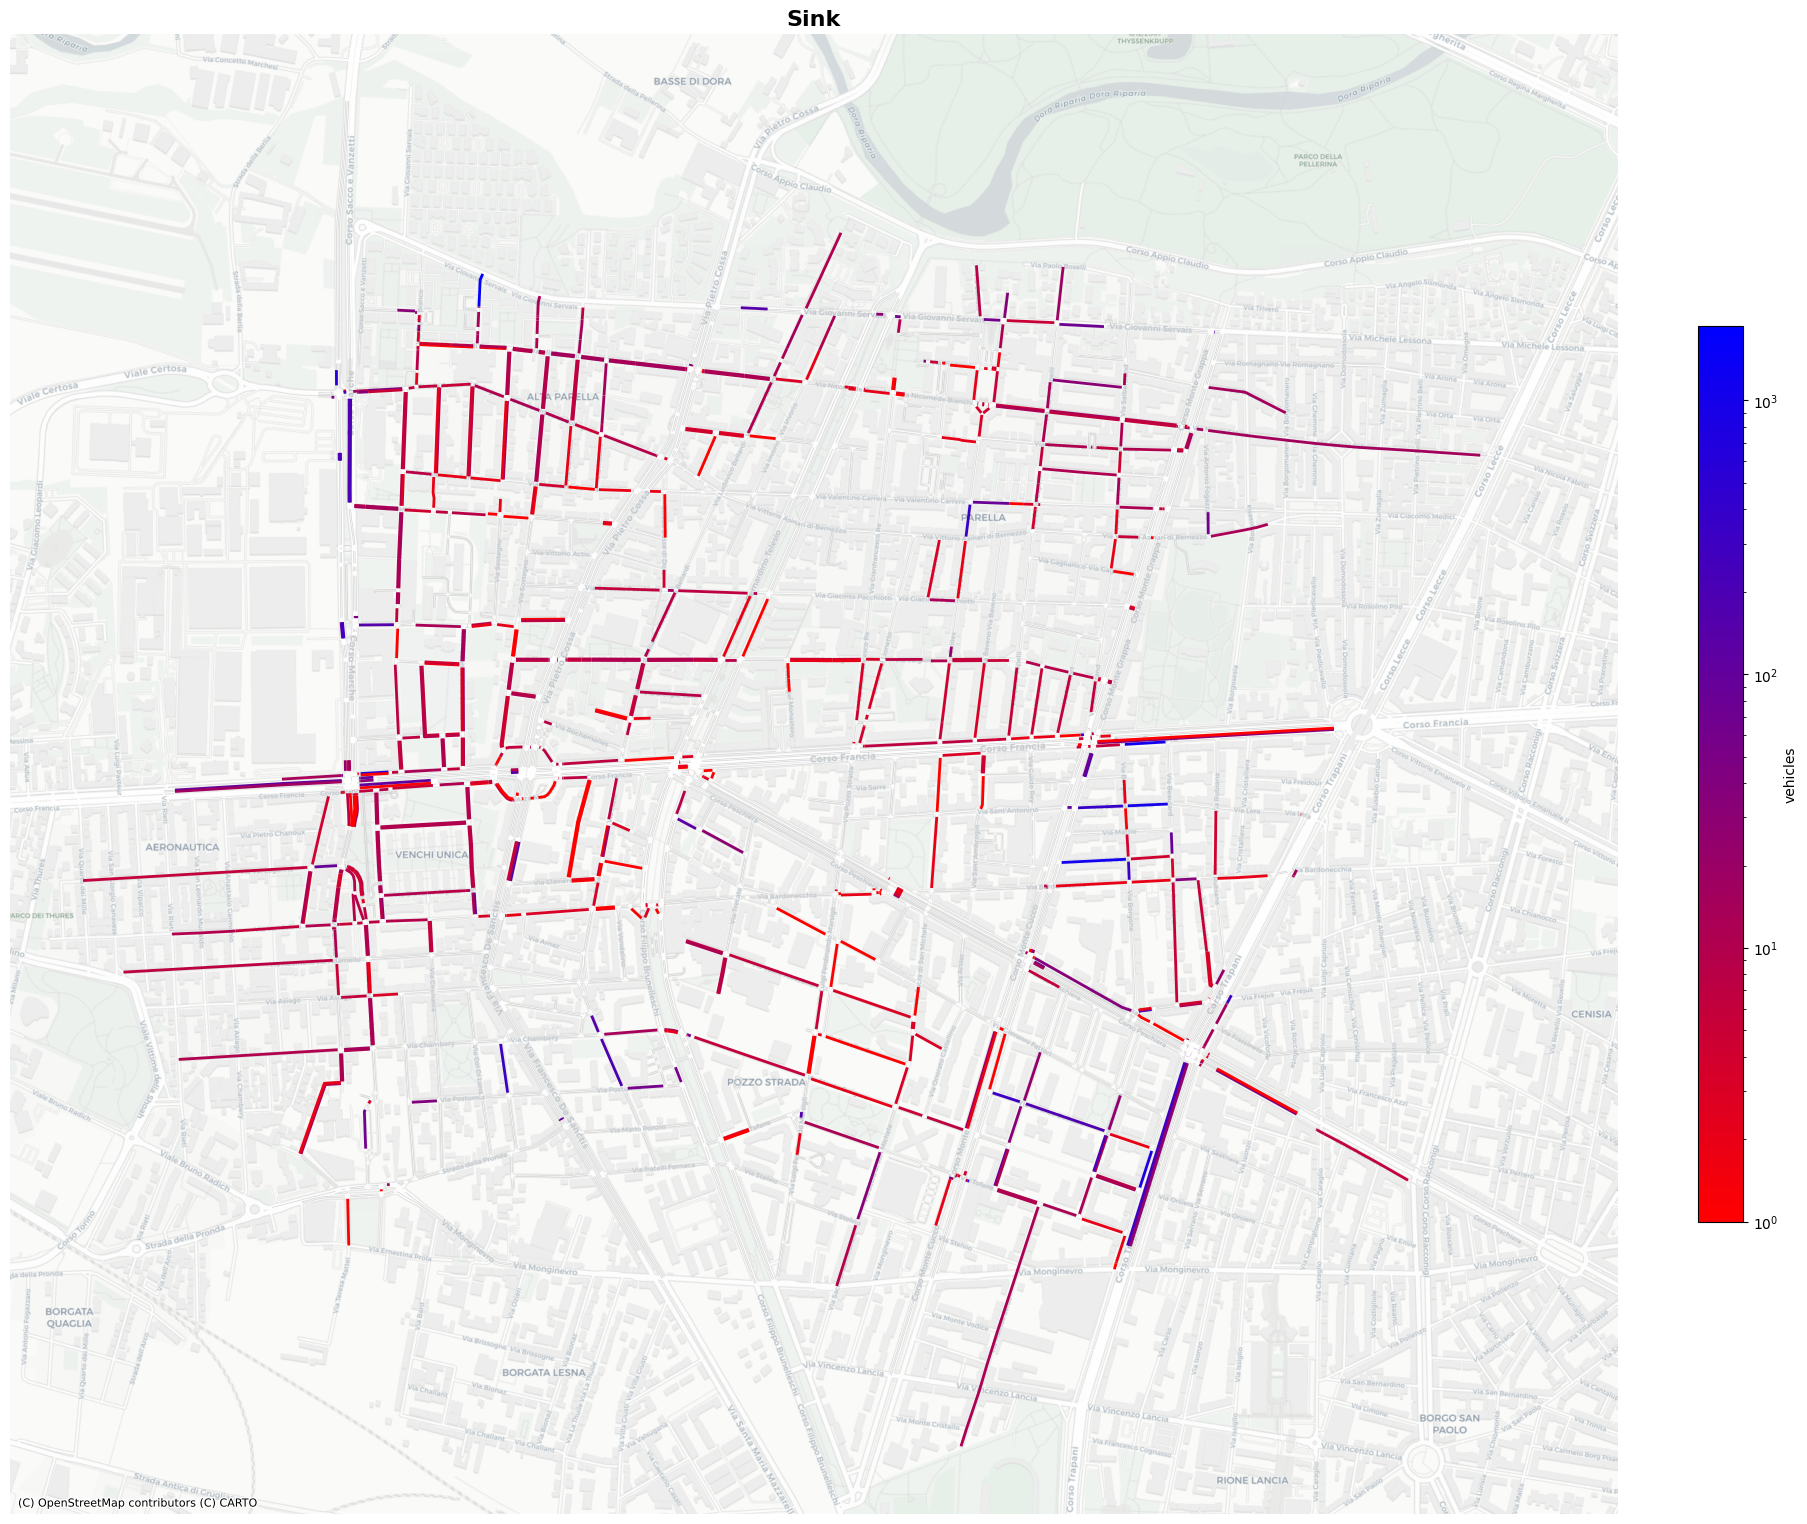

In [8]:
import matplotlib.colors as mcolors
import contextily as cx

gdf_lanes.crs = "EPSG:4326"
gdf_usage_depart.crs = "EPSG:4326"
gdf_usage_arrival.crs = "EPSG:4326"

gdf_lanes_3857 = gdf_lanes.to_crs(epsg=3857)
gdf_usage_depart_3857 = gdf_usage_depart.to_crs(epsg=3857)
gdf_usage_arrival_3857 = gdf_usage_arrival.to_crs(epsg=3857)


vmax = max(gdf_usage_depart["n_inserted"].max(), gdf_usage_arrival["n_inserted"].max())
vmin = 0

for gdf, title in zip(
        [gdf_usage_depart_3857, gdf_usage_arrival_3857], ["Source", "Sink"]
):
        fig, ax = plt.subplots(figsize=(18, 18), constrained_layout=True)
        gdf_lanes_3857.plot(ax=ax, color="lightgrey", linewidth=0.5, zorder=1)
        norm = mcolors.LogNorm(vmin=1, vmax=vmax)

        used = gdf[gdf["n_inserted"] > 0]
        used.plot(
                ax=ax,
                column="n_inserted",
                cmap=sns.blend_palette(["red", "blue"], as_cmap=True),
                norm=norm,
                linewidth=2,
                legend=True,
                zorder=2,
                legend_kwds={"label": "vehicles", "shrink": 0.5},
        )
        cx.add_basemap(
                ax=ax, source=cx.providers.CartoDB.Positron, zoom=16, zorder=0
        )
        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_axis_off()
        ax.set_aspect("equal")

Text(0.5, 1.0, 'TimeLoss per ora di partenza')

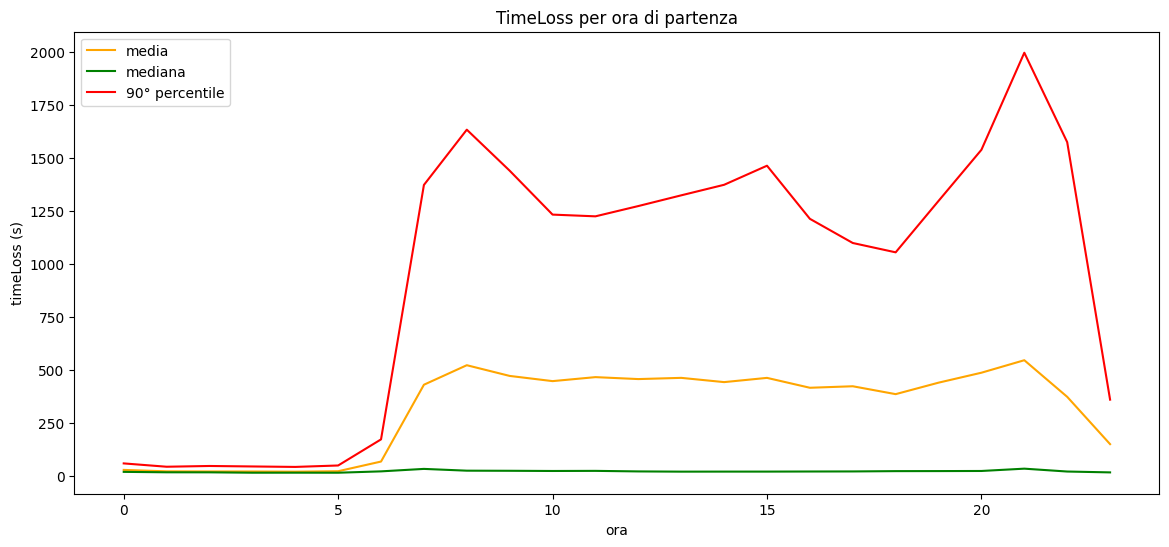

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 6))
df_res["hour"] = (df_res["depart"] // 3600).astype(int)
stats = df_res.groupby("hour")["timeLoss"].agg(["mean", "median", lambda x: x.quantile(0.9)])
stats.columns = ["mean", "median", "p90"]

ax1.plot(stats.index, stats["mean"], label="media", color="orange")
ax1.plot(stats.index, stats["median"], label="mediana", color="green")
ax1.plot(stats.index, stats["p90"], label="90° percentile", color="red")
ax1.set_xlabel("ora")
ax1.set_ylabel("timeLoss (s)")
ax1.legend()
ax1.set_title("TimeLoss per ora di partenza")